# Bulk PCA as a metric for snRNA-seq inference


Workflow (bulk PCs → snRNA metric):
1) Fit a bulk PCA “program” model (log1p(RPKM/TPM) → per-gene z-score across bulk samples → PCA), select stable PCs by bootstrap, and label/interpret PCs via curated contrasts.
   - Plots: 
   Panel A (reasoning flow), 
   Panel B (bulk PC score heatmap), 
   Panel C (PC–contrast alignment heatmap), 
   Panel D (bam-ovary direction in PC3/PC4).


2) Build bulk-space coordinates/diagnostics: a bam-ovary direction and “GSC-like” scalar coordinate, plus a convex-hull novelty score (distance-to-hull + barycentric weights) to distinguish interpolation vs extrapolation (the difference between these two terms in our context here is explained more fully below).
   - Plots: Panel E (convex-hull novelty).


3) Project snRNA nuclei (log1p-normalized expression) into the learned bulk PC space to get program scores (`X_bulk_pcs`). Project snRNA nuclei into the sample convex hull defined within PC space to understand similarity to a given sample.



In [33]:
# Cell 1 — imports
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


In [34]:
# Cell 2 — expected columns (exact, as provided)
EXPECTED_COLUMNS = [
    "FlyBase",
    "GenetID",
    "symbol",
    "Affymetrix IDs (note: // was used to separate Affy probes which owned by one gene)",
    "chrom",
    "star_chrom",
    "end_chrom",
    "bam_testis_RPKM",
    "wt_testis_RPKM",
    "bam_ovary_RPKM",
    "wt_ovary_RPKM",
    "male_carcass_RPKM",
    "female_carcass_RPKM",
]

RPKM_COLUMNS = [
    "bam_testis_RPKM",
    "wt_testis_RPKM",
    "bam_ovary_RPKM",
    "wt_ovary_RPKM",
    "male_carcass_RPKM",
    "female_carcass_RPKM",
]

META_COLUMNS = [c for c in EXPECTED_COLUMNS if c not in RPKM_COLUMNS]


In [35]:
# Cell 3 — robust CSV/TSV loader + header validation
def load_rpkm_table(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    # Try common delimiters; most robust for user-supplied "CSV" that is actually TSV.
    # We do a small sniff by reading the first line.
    with path.open("r", encoding="utf-8", errors="replace") as f:
        first_line = f.readline()
    sep = "," if first_line.count(",") >= first_line.count("\t") else "\t"

    df = pd.read_csv(path, sep=sep, dtype=str)  # read as str first; we'll coerce numerics
    # Normalize BOM / whitespace in headers
    df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]

    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    extra = [c for c in df.columns if c not in EXPECTED_COLUMNS]

    if missing:
        raise ValueError(
            "Missing required columns:\n"
            + "\n".join(f"  - {m}" for m in missing)
            + "\n\nFound columns:\n"
            + "\n".join(f"  - {c}" for c in df.columns)
        )

    if df.columns.duplicated().any():
        dupes = df.columns[df.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate column names found: {dupes[:10]}")

    if extra:
        print("Warning: extra columns found (kept, but not required):")
        for c in extra:
            print("  -", c)

    # Reorder to expected (extras appended)
    ordered = EXPECTED_COLUMNS + [c for c in df.columns if c not in EXPECTED_COLUMNS]
    df = df[ordered]

    return df


# Example:
# df_raw = load_rpkm_table("your_file.csv")
# df_raw.head()


In [36]:
# Cell 4 — cleaning: coercing RPKM columns to numeric, handling weird tokens
_NUMERIC_BAD_TOKENS = {"", "NA", "NaN", "nan", "null", "NULL", "None", ".", "-"}


def coerce_rpkm_numeric(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for c in RPKM_COLUMNS:
        s = df[c].astype(str).str.strip()

        # Normalize commas in numbers (e.g. "1,234.5") and remove stray spaces
        s = s.str.replace(",", "", regex=False)

        # Replace common missing tokens
        s = s.where(~s.isin(_NUMERIC_BAD_TOKENS), other=np.nan)

        df[c] = pd.to_numeric(s, errors="coerce")

    # Optional: chrom coords to ints if possible
    for c in ["star_chrom", "end_chrom"]:
        if c in df.columns:
            s = df[c].astype(str).str.strip().str.replace(",", "", regex=False)
            s = s.where(~s.isin(_NUMERIC_BAD_TOKENS), other=np.nan)
            df[c] = pd.to_numeric(s, errors="coerce")

    return df


# Example:
# df = coerce_rpkm_numeric(df_raw)
# df[RPKM_COLUMNS].describe()


In [37]:
# Cell 5 — normalize/standardize identifiers and split Affymetrix IDs
def split_affy_ids(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    affy_col = "Affymetrix IDs (note: // was used to separate Affy probes which owned by one gene)"

    # Keep original column as-is, and add a list-like column
    def _split(x: str) -> List[str]:
        if x is None:
            return []
        x = str(x).strip()
        if x in _NUMERIC_BAD_TOKENS:
            return []
        parts = [p.strip() for p in x.split("//")]
        return [p for p in parts if p]

    df["affy_ids_list"] = df[affy_col].map(_split)
    df["affy_ids_n"] = df["affy_ids_list"].map(len)
    return df


# Example:
# df = split_affy_ids(df)
# df[["symbol", "affy_ids_n", "affy_ids_list"]].head()


In [38]:
# Cell 6 — build analysis matrices: wide (genes×samples), long tidy
def build_matrices(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      X_wide: index=gene key, columns=RPKM sample columns
      tidy: long format with metadata + (tissue, genotype, sex) parsed from sample name
    """
    df = df.copy()

    # Choose a stable gene key. Prefer FlyBase if present.
    gene_key = "FlyBase" if ("FlyBase" in df.columns and not df["FlyBase"].isna().all()) else "symbol"
    if gene_key not in df.columns:
        raise ValueError("No gene identifier column found (expected 'FlyBase' or 'symbol').")

    # Ensure uniqueness
    key_series = df[gene_key].astype(str)
    if key_series.duplicated().any():
        df["_gene_key"] = df["FlyBase"].astype(str) + "|" + df["symbol"].astype(str)
        gene_key = "_gene_key"

    # Wide matrix
    X_wide = df.set_index(gene_key)[RPKM_COLUMNS].copy()
    X_wide.index.name = "gene"

    # Long / tidy
    id_vars = [gene_key] + [c for c in META_COLUMNS if c != gene_key]
    tidy = df[id_vars + RPKM_COLUMNS].melt(
        id_vars=id_vars,
        value_vars=RPKM_COLUMNS,
        var_name="sample",
        value_name="rpkm",
    )
    tidy["gene"] = tidy[gene_key]

    # Parse sample into genotype/tissue/sex-ish fields by your naming convention
    # Columns: bam_testis_RPKM, wt_ovary_RPKM, male_carcass_RPKM, ...
    def parse_sample(s: str) -> Dict[str, str]:
        base = s.replace("_RPKM", "")
        parts = base.split("_")
        out = {"genotype": "unknown", "tissue": "unknown", "sex": "unknown"}
        if len(parts) == 2:
            out["genotype"], out["tissue"] = parts
        elif len(parts) == 3:
            out["sex"], out["tissue"], out["genotype"] = parts[0], parts[1], parts[2]
        elif len(parts) == 1:
            out["tissue"] = parts[0]
        else:
            # Best-effort:
            out["genotype"] = parts[0]
            out["tissue"] = "_".join(parts[1:])
        # Special case: male/female carcass are sex, not genotype
        if parts and parts[0] in ("male", "female") and "carcass" in parts:
            out["sex"] = parts[0]
            out["tissue"] = "carcass"
            out["genotype"] = "unknown"
        return out

    parsed = tidy["sample"].map(parse_sample).apply(pd.Series)
    tidy = pd.concat([tidy, parsed], axis=1)

    # Put the essentials first
    first_cols = ["gene", "sample", "tissue", "genotype", "sex", "rpkm"]
    other_cols = [c for c in tidy.columns if c not in first_cols]
    tidy = tidy[first_cols + other_cols]

    return X_wide, tidy


# Example:
# X_wide, tidy = build_matrices(df)
# X_wide.shape, tidy.head()


In [39]:
# Cell 7 — basic QC: missingness, zeros, distributions
def log1p_rpkm_matrix(X_wide: pd.DataFrame) -> pd.DataFrame:
    X = X_wide.copy()
    if (X.to_numpy(dtype=float, copy=False) < 0).any():
        raise ValueError("RPKM matrix contains negative values; expected non-negative.")
    return np.log1p(X.astype(float))


def qc_report(X_wide: pd.DataFrame) -> pd.DataFrame:
    X = X_wide.copy()
    report = pd.DataFrame(index=X.columns)
    report["n_genes"] = X.shape[0]
    report["n_missing"] = X.isna().sum(axis=0)
    report["missing_frac"] = report["n_missing"] / report["n_genes"]
    report["n_zero"] = (X.fillna(0.0) == 0.0).sum(axis=0)
    report["zero_frac"] = report["n_zero"] / report["n_genes"]
    report["median_rpkm"] = X.median(axis=0, skipna=True)
    report["mean_rpkm"] = X.mean(axis=0, skipna=True)
    return report


def plot_basic_qc(X_wide: pd.DataFrame, *, use_log1p: bool = True) -> pd.DataFrame:
    """Return qc report and show a few quick plots."""
    qc = qc_report(X_wide)

    # Missingness / zeros
    x = np.arange(len(qc.index))
    plt.figure(figsize=(8, 3))
    plt.bar(x - 0.2, qc["missing_frac"].to_numpy(), width=0.4, label="missing")
    plt.bar(x + 0.2, qc["zero_frac"].to_numpy(), width=0.4, label="zero")
    plt.xticks(x, qc.index.to_list(), rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Fraction of genes")
    plt.title("Per-sample missingness and zeros")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Distributions
    X = X_wide.fillna(0.0)
    if use_log1p:
        X = log1p_rpkm_matrix(X)
        ylabel = "log1p(RPKM)"
        title = "Expression distributions (log1p)"
    else:
        ylabel = "RPKM"
        title = "Expression distributions"

    plt.figure(figsize=(8, 3))
    plt.boxplot([X[c].to_numpy() for c in X.columns], labels=X.columns, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # Sample–sample correlations
    corr = X.corr(method="pearson")
    plt.figure(figsize=(4, 3))
    im = plt.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="viridis")
    plt.colorbar(im, label="Pearson r")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Sample correlation" + (" (log1p)" if use_log1p else ""))
    plt.tight_layout()
    plt.show()

    return qc


# Example:
# qc = qc_report(X_wide)
# qc
# qc = plot_basic_qc(X_wide)


In [40]:
# Cell 8 — PCA programs on bulk (log1p then per-gene zscore across samples)
@dataclass
class BulkPCAModel:
    genes: List[str]
    mu: np.ndarray        # per-gene mean on log1p scale (shape G,)
    sigma: np.ndarray     # per-gene std  on log1p scale (shape G,)
    loadings: np.ndarray  # shape (G, K)
    pc: PCA               # fitted sklearn PCA object
    k: int


def fit_bulk_pca(X_wide: pd.DataFrame, k: int = 50, min_nonmissing_frac: float = 0.8) -> BulkPCAModel:
    """
    X_wide: genes × samples RPKM
    Returns PCA over samples, but stores gene loadings (genes×K).
    """
    X = X_wide.copy()

    # Filter genes with enough observed values
    nonmissing_frac = 1.0 - X.isna().mean(axis=1)
    X = X.loc[nonmissing_frac >= min_nonmissing_frac].copy()

    # Fill remaining missing with 0 RPKM (conservative for bulk); alternative: gene median
    X = X.fillna(0.0)

    # log1p transform
    Xlog = log1p_rpkm_matrix(X).to_numpy()  # shape (G, S)

    # Per-gene z-score across samples (important for transfer projection)
    mu = Xlog.mean(axis=1)
    sigma = Xlog.std(axis=1, ddof=1)
    sigma = np.where(sigma < 1e-8, 1.0, sigma)
    Z = (Xlog - mu[:, None]) / sigma[:, None]

    # PCA is usually done on samples; we want gene loadings for projection.
    # Transpose: samples × genes
    Zs = Z.T

    pc = PCA(n_components=min(k, Zs.shape[0], Zs.shape[1]), random_state=0)
    pc.fit(Zs)
    # sklearn components_: K × genes. Loadings genes × K:
    loadings = pc.components_.T

    return BulkPCAModel(
        genes=list(X.index.astype(str)),
        mu=mu.astype(np.float64),
        sigma=sigma.astype(np.float64),
        loadings=loadings.astype(np.float64),
        pc=pc,
        k=loadings.shape[1],
    )


# Example:
# model = fit_bulk_pca(X_wide, k=20)
# model.k, model.loadings.shape


In [41]:
# Cell 9 — inspect PCA: variance explained and sample scores
def plot_pca_variance(model: BulkPCAModel, max_k: int = 30) -> None:
    evr = model.pc.explained_variance_ratio_
    k = min(max_k, len(evr))
    plt.figure()
    plt.plot(np.arange(1, k + 1), evr[:k], marker="o")
    plt.xlabel("PC")
    plt.ylabel("Explained variance ratio")
    plt.title("Bulk PCA explained variance")
    plt.show()


def get_bulk_sample_scores(model: BulkPCAModel, X_wide: pd.DataFrame) -> pd.DataFrame:
    """
    Returns sample scores (samples × K) for the same samples used to train.
    """
    X = X_wide.loc[model.genes].fillna(0.0)
    Xlog = log1p_rpkm_matrix(X).to_numpy()
    Z = (Xlog - model.mu[:, None]) / model.sigma[:, None]
    scores = model.pc.transform(Z.T)  # samples × K
    return pd.DataFrame(
        scores,
        index=X_wide.columns,
        columns=[f"bulkPC{i+1}" for i in range(scores.shape[1])],
    )


# Example:
# plot_pca_variance(model)
# scores = get_bulk_sample_scores(model, X_wide)
# scores


In [42]:
# Cell 10 — program gene lists (top loaded genes per PC)
def top_genes_per_pc(
    model: BulkPCAModel,
    top_n: int = 50,
    use_abs: bool = True,
) -> Dict[str, pd.DataFrame]:
    """
    Returns dict: PC -> dataframe of top genes with loading
    """
    L = model.loadings  # G×K
    out: Dict[str, pd.DataFrame] = {}
    genes = np.array(model.genes)

    for j in range(L.shape[1]):
        w = L[:, j]
        order = np.argsort(np.abs(w) if use_abs else w)[::-1][:top_n]
        df = pd.DataFrame({"gene": genes[order], "loading": w[order]})
        out[f"bulkPC{j+1}"] = df

    return out


# Example:
# tops = top_genes_per_pc(model, top_n=25)
# tops["bulkPC1"].head(10)


In [43]:
# Cell 11 — glue for snRNA downstream projection (interface only)
def project_sn_to_bulk_pcs(
    model: BulkPCAModel,
    sn_expr_log1p: pd.DataFrame,
) -> pd.DataFrame:
    """
    Project snRNA nuclei into bulk PCA space.

    sn_expr_log1p:
      DataFrame with index = genes, columns = nuclei/cells
      Values should already be log1p normalized expression (not raw counts).

    Returns:
      nuclei × K bulk PC scores
    """
    # Align gene sets
    model_genes = list(model.genes)
    common = [g for g in model_genes if g in sn_expr_log1p.index]
    if len(common) < max(200, int(0.1 * len(model_genes))):
        raise ValueError(f"Too few genes overlap between bulk PCA genes and snRNA matrix: {len(common)}")

    gene_to_idx = {g: i for i, g in enumerate(model_genes)}
    idx = np.array([gene_to_idx[g] for g in common], dtype=int)

    # Extract bulk stats for common genes
    mu = model.mu[idx]
    sigma = model.sigma[idx]
    L = model.loadings[idx, :]  # common_genes × K

    X = sn_expr_log1p.loc[common].to_numpy()  # common_genes × cells
    Z = (X - mu[:, None]) / sigma[:, None]

    # scores = Zᵀ L
    scores = Z.T @ L  # cells × K
    return pd.DataFrame(
        scores,
        index=sn_expr_log1p.columns,
        columns=[f"bulkPC{i+1}" for i in range(scores.shape[1])],
    )


# You'd call this after you produce a gene×cell log1p expression layer from your snRNA object.


In [44]:
import pathlib
import sys
import warnings

# Make repo-local code importable no matter where the notebook is launched from.
here = pathlib.Path().resolve()
repo_root = here
markers = [
    "snrna_bulk_pca_metric",  # repo-local package
    "environment.workshop.yml",  # repo root marker in this repo
    ".git",  # present if cloned via git
]

while repo_root != repo_root.parent and not any((repo_root / m).exists() for m in markers):
    repo_root = repo_root.parent

# Add repo-root (and optionally src/) to the import path.
sys.path.insert(0, str(repo_root))
src_dir = repo_root / "src"
if src_dir.exists():
    sys.path.insert(0, str(src_dir))

# Optional: silence a noisy joblib warning on some macOS setups.
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores*",
    category=UserWarning,
)
print("Repo root:", repo_root)


Repo root: /Users/mattw/code/bulk_seq_workshop


In [45]:
import numpy as np
import pandas as pd

from snrna_bulk_pca_metric import (
    bootstrap_pc_stability,
    fit_bulk_pca_model,
    knn_indices_distances,
    project_log1p_to_bulk_pcs,
)


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
sns.set_style("whitegrid")


## Inputs

Expected files (edit as needed):
- Bulk controls: `data/bulk_controls_rpkm.tsv` (samples×genes matrix, or the annotated gene table with required headers)
- snRNA AnnData: `data/snrna.h5ad`

If a file is missing, the notebook runs on a toy dataset so you can validate the plumbing.


In [47]:
from pathlib import Path

DATA_DIR = repo_root / "data"
RESULTS_DIR = repo_root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

BULK_PATH = DATA_DIR / "RNAseqRPKM-gene.xlsx - all_genes.csv"
SNRNA_PATH = DATA_DIR / "snrna.h5ad"

BULK_PATH, SNRNA_PATH


(PosixPath('/Users/mattw/code/bulk_seq_workshop/data/RNAseqRPKM-gene.xlsx - all_genes.csv'),
 PosixPath('/Users/mattw/code/bulk_seq_workshop/data/snrna.h5ad'))

## 0) Learn bulk programs (control-only bulk PCA)

Bulk is treated as geometry only: `log1p(RPKM)` → per-gene z-score across bulk samples → PCA.


In [48]:
def sniff_sep(path: Path) -> str:
    with path.open("r", encoding="utf-8", errors="replace") as f:
        first_line = f.readline()
    return "," if first_line.count(",") >= first_line.count("\t") else "\t"

bulk_df_raw = None
bulk_df = None
bulk_X_wide = None
bulk_tidy = None

if BULK_PATH.exists():
    sep = sniff_sep(BULK_PATH)
    cols = pd.read_csv(BULK_PATH, sep=sep, nrows=0).columns
    cols = [str(c).strip().lstrip("\ufeff") for c in cols]

    if set(EXPECTED_COLUMNS).issubset(cols):
        bulk_df_raw = load_rpkm_table(BULK_PATH)
        bulk_df = coerce_rpkm_numeric(bulk_df_raw)
        bulk_df = split_affy_ids(bulk_df)
        bulk_X_wide, bulk_tidy = build_matrices(bulk_df)
        bulk_rpkm = bulk_X_wide.fillna(0.0).T  # samples×genes
        print("Loaded annotated bulk table:", bulk_df.shape, "-> bulk matrix:", bulk_rpkm.shape)
    else:
        bulk_rpkm = pd.read_csv(BULK_PATH, sep=sep, index_col=0)
        bulk_rpkm = bulk_rpkm.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        print("Loaded bulk matrix:", bulk_rpkm.shape)
else:
    rng = np.random.default_rng(0)
    n_samples = 30
    n_genes = 2000
    genes = np.array([f"G{g:04d}" for g in range(n_genes)], dtype=str)

    # Toy bulk: 3 latent programs + noise in log space
    programs = rng.normal(size=(3, n_genes))
    programs /= np.linalg.norm(programs, axis=1, keepdims=True)
    scores = rng.normal(size=(n_samples, 3))
    log_expr = scores @ programs + rng.normal(scale=0.35, size=(n_samples, n_genes))

    rpkm = np.expm1(log_expr - log_expr.min() + 1.0)
    bulk_rpkm = pd.DataFrame(
        rpkm,
        index=[f"bulk{i:02d}" for i in range(n_samples)],
        columns=genes,
    )
    print("BULK_PATH not found; using toy bulk:", bulk_rpkm.shape)

bulk_rpkm.iloc[:6, :5]


Loaded annotated bulk table: (15141, 15) -> bulk matrix: (6, 15141)


gene,FBgn0029514,FBgn0028550,FBgn0011710,FBgn0014029,FBgn0026361
bam_testis_RPKM,8.65431,10.66950,57.3817,178.4170,27.395300
wt_testis_RPKM,10.78120,2.87558,31.4231,43.3863,3.846070
bam_ovary_RPKM,9.43994,28.65550,67.6365,160.0090,23.115700
wt_ovary_RPKM,14.23950,5.81675,75.0797,110.2910,14.785800
male_carcass_RPKM,8.38939,11.84230,27.5395,47.2204,0.400511
female_carcass_RPKM,9.36238,10.53970,29.7038,49.2713,0.343478


### Running PCA on the (6, 15141) bulk matrix

In [49]:
model, bulk_scores = fit_bulk_pca_model(
    bulk_rpkm,
    gene_min_frac=0.25,
    n_components=50,
    random_state=0,
)

print("Bulk PCA model:")
print("  genes:", model.n_genes)
print("  PCs:", model.n_pcs)
print("  bulk_scores:", bulk_scores.shape)


Bulk PCA model:
  genes: 13433
  PCs: 5
  bulk_scores: (6, 5)


In [50]:
# ----------------------------
# Input: bulk_scores (6 samples × 5 PCs) in the confirmed ordering:
# bam_testis_RPKM, wt_testis_RPKM, bam_ovary_RPKM, wt_ovary_RPKM, male_carcass_RPKM, female_carcass_RPKM
# ----------------------------


sample_names = [
    "bam_testis_RPKM",
    "wt_testis_RPKM",
    "bam_ovary_RPKM",
    "wt_ovary_RPKM",
    "male_carcass_RPKM",
    "female_carcass_RPKM",
]
pc_names = [f"PC{i}" for i in range(1, 6)]

bulk_scores_df = pd.DataFrame(bulk_scores, index=sample_names, columns=pc_names)
bulk_scores_df

,PC1,PC2,PC3,PC4,PC5
bam_testis_RPKM,-46.698585,47.717444,41.083957,54.351932,4.832079
wt_testis_RPKM,-80.976072,-138.065639,-2.977598,-4.840887,0.143017
bam_ovary_RPKM,-21.934418,53.403280,42.335115,-55.754918,-2.920319
wt_ovary_RPKM,-58.266240,71.531029,-67.460656,-1.468097,-3.413580
male_carcass_RPKM,106.569844,-20.648133,-1.824751,10.714536,-31.033831
female_carcass_RPKM,101.305470,-13.937981,-11.156068,-3.002566,32.392632


In [51]:
# (1) Bulk PCA score matrix summary
def summarize_bulk_pca_scores(df: pd.DataFrame) -> str:
    return (
        "Bulk PCA score matrix:\n"
        f"  samples: {df.shape[0]}\n"
        f"  PCs: {df.shape[1]}\n"
        f"  shape: {df.shape}\n"
        f"  sample order: {', '.join(df.index.tolist())}\n"
    )

print(summarize_bulk_pca_scores(bulk_scores_df))

Bulk PCA score matrix:
  samples: 6
  PCs: 5
  shape: (6, 5)
  sample order: bam_testis_RPKM, wt_testis_RPKM, bam_ovary_RPKM, wt_ovary_RPKM, male_carcass_RPKM, female_carcass_RPKM



In [52]:
# (2) Formal contrast alignment (cosine similarity) for PC labeling

def cosine_alignment(s: np.ndarray, c: np.ndarray) -> float:
    s = np.asarray(s, float)
    c = np.asarray(c, float)
    denom = (np.linalg.norm(s) * np.linalg.norm(c))
    if denom == 0:
        return np.nan
    return float(np.dot(s, c) / denom)

# Contrast vectors are length-6 arrays aligned to bulk_scores_df.index order:
#   bam_testis_RPKM, wt_testis_RPKM, bam_ovary_RPKM, wt_ovary_RPKM, male_carcass_RPKM, female_carcass_RPKM
contrasts = {
    "gonad_vs_carcass": np.array([+1, +1, +1, +1, -2, -2], dtype=float),
    "testis_vs_ovary":  np.array([+1, +1, -1, -1, 0, 0], dtype=float),
    "bam_vs_wt_ovary":  np.array([0, 0, +1, -1, 0, 0], dtype=float),
    "bam_vs_wt_testis": np.array([+1, -1, 0, 0, 0, 0], dtype=float),
    "bam_interaction":  np.array([-1, +1, +1, -1, 0, 0], dtype=float),  # (bam-wt) ovary minus (bam-wt) testis
    "male_vs_female_carcass": np.array([0, 0, 0, 0, +1, -1], dtype=float),
}

alignment_rows = []
for pc in pc_names:
    s = bulk_scores_df[pc].values
    row = {"PC": pc}
    for name, c in contrasts.items():
        row[name] = cosine_alignment(s, c)
    alignment_rows.append(row)

alignment_df = pd.DataFrame(alignment_rows).set_index("PC")
alignment_df

,gonad_vs_carcass,testis_vs_ovary,bam_vs_wt_ovary,bam_vs_wt_testis,bam_interaction,male_vs_female_carcass
PC,,,,,,
PC1,-0.972983,-0.128291,0.138849,0.130998,0.005552,0.020119
PC2,0.173138,-0.622211,-0.074095,0.759364,-0.589345,-0.027427
PC3,0.124389,0.349828,0.859052,0.344742,0.363672,0.073009
PC4,-0.084737,0.677099,-0.487033,0.531047,-0.719891,0.123063
PC5,-0.025953,0.124707,0.007692,0.073125,-0.046268,-0.989125


In [53]:


# (3) PC labels chosen by max |alignment| among the curated contrasts
#
# Each contrast vector sums to zero.
#
# Because the PCA scores are centered around zero too, the cosine alignment is the Pearson
# correlation between the PC and the contrast direction defined.
#
# So, the contrasts are defined explicitly to tease apart pairwise differences that we
# wish to learn from the bulk data. (Dict key order doesn't matter for contrasts itself here 
# because we take an argmax over the whole thing to find which contrast is best matched to each PC.)


label_candidates = list(contrasts.keys())

labels = {}
for pc in alignment_df.index:
    vals = alignment_df.loc[pc, label_candidates]
    best = vals.abs().idxmax()
    labels[pc] = best

labels_df = pd.DataFrame({"label": pd.Series(labels)})
labels_df

,label
PC1,gonad_vs_carcass
PC2,bam_vs_wt_testis
PC3,bam_vs_wt_ovary
PC4,bam_interaction
PC5,male_vs_female_carcass


In [54]:
# (4) "bam ovary" axis contributions per PC
# d_bam_ovary = x(bam_ovary) - x(wt_ovary)

x_bam_ovary = bulk_scores_df.loc["bam_ovary_RPKM"].values
x_wt_ovary  = bulk_scores_df.loc["wt_ovary_RPKM"].values
d_bam_ovary = x_bam_ovary - x_wt_ovary

delta = pd.Series(d_bam_ovary, index=pc_names, name="delta_bam_minus_wt_ovary")
delta_sq = delta**2
contrib = delta_sq / delta_sq.sum()

bam_contrib_df = pd.DataFrame({
    "delta": delta,
    "delta_sq": delta_sq,
    "contrib_frac": contrib,
}).sort_values("contrib_frac", ascending=False)

bam_contrib_df

,delta,delta_sq,contrib_frac
PC3,109.795771,12055.111339,0.723986
PC4,-54.286822,2947.058994,0.176990
PC1,36.331821,1320.001231,0.079274
PC2,-18.127749,328.615285,0.019735
PC5,0.493261,0.243307,0.000015


In [55]:
def label_pcs_with_margin(
    alignment_df: pd.DataFrame,
    candidate_contrasts: list[str],
    margin: float = 0.15,
) -> pd.DataFrame:
    """
    Labels PCs using:
      - compute alignment to all candidate contrasts
      - choose best by max |alignment|
      - assign best label only if it beats runner-up by Δ >= margin
      - otherwise label 'mixed' and report top-2

    Returns a DataFrame with best/second, signed alignments, and Δ.
    """
    rows = []
    for pc in alignment_df.index:
        s = alignment_df.loc[pc, candidate_contrasts].astype(float)

        # Rank by absolute alignment
        abs_sorted = s.abs().sort_values(ascending=False)
        best_name = abs_sorted.index[0]
        second_name = abs_sorted.index[1] if len(abs_sorted) > 1 else None

        best_val = float(s[best_name])
        second_val = float(s[second_name]) if second_name is not None else np.nan

        delta = float(abs(best_val) - abs(second_val)) if second_name is not None else np.inf

        if delta >= margin:
            label = best_name
            label_type = "single"
        else:
            label = f"mixed({best_name}, {second_name})"
            label_type = "mixed"

        rows.append({
            "PC": pc,
            "label": label,
            "label_type": label_type,
            "best_contrast": best_name,
            "best_alignment": best_val,
            "runnerup_contrast": second_name,
            "runnerup_alignment": second_val,
            "delta_abs": delta,
        })

    out = pd.DataFrame(rows).set_index("PC")

    # Optional: include the full alignment row for transparency (comment out if too wide)
    out = out.join(alignment_df[candidate_contrasts])

    return out


candidate_contrasts = list(contrasts.keys())
pc_label_report = label_pcs_with_margin(alignment_df, candidate_contrasts, margin=0.15)
pc_label_report

,label,label_type,best_contrast,best_alignment,runnerup_contrast,runnerup_alignment,delta_abs,gonad_vs_carcass,testis_vs_ovary,bam_vs_wt_ovary,bam_vs_wt_testis,bam_interaction,male_vs_female_carcass
PC,,,,,,,,,,,,,
PC1,gonad_vs_carcass,single,gonad_vs_carcass,-0.972983,bam_vs_wt_ovary,0.138849,0.834134,-0.972983,-0.128291,0.138849,0.130998,0.005552,0.020119
PC2,"mixed(bam_vs_wt_testis, testis_vs_ovary)",mixed,bam_vs_wt_testis,0.759364,testis_vs_ovary,-0.622211,0.137153,0.173138,-0.622211,-0.074095,0.759364,-0.589345,-0.027427
PC3,bam_vs_wt_ovary,single,bam_vs_wt_ovary,0.859052,bam_interaction,0.363672,0.495380,0.124389,0.349828,0.859052,0.344742,0.363672,0.073009
PC4,"mixed(bam_interaction, testis_vs_ovary)",mixed,bam_interaction,-0.719891,testis_vs_ovary,0.677099,0.042793,-0.084737,0.677099,-0.487033,0.531047,-0.719891,0.123063
PC5,male_vs_female_carcass,single,male_vs_female_carcass,-0.989125,testis_vs_ovary,0.124707,0.864418,-0.025953,0.124707,0.007692,0.073125,-0.046268,-0.989125


In [56]:
# Optional: compact view of the bulk PC score matrix with margin-based PC labels appended.
# (This is redundant with pc_label_report, but can be easier to read alongside the scores.)
labels_row = pc_label_report["label"].reindex(bulk_scores_df.columns).to_frame().T
labels_row.index = ["PC_label_margin"]

display_table_margin = pd.concat([bulk_scores_df, labels_row], axis=0, sort=False)
display_table_margin

,PC1,PC2,PC3,PC4,PC5
bam_testis_RPKM,-46.698585,47.717444,41.083957,54.351932,4.832079
wt_testis_RPKM,-80.976072,-138.065639,-2.977598,-4.840887,0.143017
bam_ovary_RPKM,-21.934418,53.40328,42.335115,-55.754918,-2.920319
wt_ovary_RPKM,-58.26624,71.531029,-67.460656,-1.468097,-3.41358
male_carcass_RPKM,106.569844,-20.648133,-1.824751,10.714536,-31.033831
female_carcass_RPKM,101.30547,-13.937981,-11.156068,-3.002566,32.392632
PC_label_margin,gonad_vs_carcass,"mixed(bam_vs_wt_testis, testis_vs_ovary)",bam_vs_wt_ovary,"mixed(bam_interaction, testis_vs_ovary)",male_vs_female_carcass


In [57]:
# (5) gsc-like (bc of bam knockout) scalar coordinate function + gsc-like score for the 6 samples
# gsc_like(wt_ovary)=0, gsc_like(bam_ovary)=1

def gsc_like(x: np.ndarray, x_ref: np.ndarray, d: np.ndarray) -> float:
    x = np.asarray(x, float)
    num = np.dot(x - x_ref, d)
    den = np.dot(d, d)
    return float(num / den) if den > 0 else np.nan

gsc_likeness_scores = {name: gsc_like(bulk_scores_df.loc[name].values, x_wt_ovary, d_bam_ovary)
                  for name in bulk_scores_df.index}
gsc_likeness_df = pd.DataFrame({"GSC-like": pd.Series(gsc_likeness_scores)})
gsc_likeness_df

,GSC-like
bam_testis_RPKM,0.585158
wt_testis_RPKM,0.614932
bam_ovary_RPKM,1.000000
wt_ovary_RPKM,0.000000
male_carcass_RPKM,0.852281
female_carcass_RPKM,0.818560


In [58]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Convex-hull novelty score (distance to convex hull of the 6 bulk points)
#
# Here, each bulk sample is a vertex in bulk PC-space.
# Hull projection computes the closest point on the convex hull formed by the 6 bulk sample vertices.

V = bulk_scores_df  # 6×5 vertices
Vt = V.T  # 5×6
vertex_names = bulk_scores_df.index.to_list()

def hull_projection(x: np.ndarray, Vt: np.ndarray, tol: float = 1e-10):
    """
    Solve: min_{a>=0, sum(a)=1} || x - Vt @ a ||^2
    Returns (dist, a, y) where y is the closest point in the hull and a are barycentric weights.
    """
    x = np.asarray(x, float)
    m = Vt.shape[1]

    def obj(a):
        r = x - Vt @ a
        return float(np.dot(r, r))

    def grad(a):
        r = x - Vt @ a
        return (-2.0 * (Vt.T @ r)).astype(float)

    cons = ({
        "type": "eq",
        "fun": lambda a: np.sum(a) - 1.0,
        "jac": lambda a: np.ones_like(a),
    },)
    bounds = [(0.0, 1.0) for _ in range(m)]
    a0 = np.full(m, 1.0 / m)

    res = minimize(
        obj,
        a0,
        jac=grad,
        bounds=bounds,
        constraints=cons,
        method="SLSQP",
        options={"ftol": tol, "maxiter": 2000, "disp": False},
    )
    if not res.success:
        raise RuntimeError(f"Hull projection failed: {res.message}")

    a = res.x
    y = Vt @ a
    dist = float(np.linalg.norm(x - y))
    return dist, a, y

def hull_projection_named(x: np.ndarray, *, tol: float = 1e-10) -> tuple[float, pd.Series, np.ndarray]:
    dist, a, y = hull_projection(x, Vt, tol=tol)
    weights = pd.Series(a, index=vertex_names, name="weight")
    return dist, weights, y

def novelty(x: np.ndarray) -> float:
    dist, _, _ = hull_projection(x, Vt)
    return dist

# Sanity check: bulk samples are inside their own hull (novelty ~ 0).
# Also return the (named) barycentric weights for the closest in-hull point.
rows = []
for name in vertex_names:
    dist, weights, _ = hull_projection_named(bulk_scores_df.loc[name].values)
    rows.append({
        "novelty": dist,
        **{f"w_{k}": float(v) for k, v in weights.items()},
    })

novelty_df = pd.DataFrame(rows, index=vertex_names)
novelty_df

,novelty,w_bam_testis_RPKM,w_wt_testis_RPKM,w_bam_ovary_RPKM,w_wt_ovary_RPKM,w_male_carcass_RPKM,w_female_carcass_RPKM
bam_testis_RPKM,1.540371e-10,1.000000e+00,1.028149e-12,4.530405e-13,0.000000e+00,0.000000e+00,0.000000e+00
wt_testis_RPKM,3.156597e-11,4.892188e-15,1.000000e+00,0.000000e+00,0.000000e+00,1.192749e-13,1.202196e-13
bam_ovary_RPKM,1.216227e-10,0.000000e+00,7.855372e-13,1.000000e+00,2.020779e-13,0.000000e+00,0.000000e+00
wt_ovary_RPKM,3.333464e-12,8.080046e-15,0.000000e+00,1.273095e-14,1.000000e+00,6.295016e-15,2.031995e-14
male_carcass_RPKM,1.174108e-11,0.000000e+00,0.000000e+00,2.270306e-14,5.325571e-14,1.000000e+00,7.398162e-14
female_carcass_RPKM,5.992559e-09,0.000000e+00,3.741584e-11,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [59]:
# Recreate table: 6×5 with a PC label row + bam-ovary contribution row

pc_label_map = {
    "PC1": "gonad_vs_carcass",
    "PC2": labels["PC2"],  # auto-chosen by contrast alignment
    "PC3": "bam_vs_wt_ovary (bam-ness primary)",
    "PC4": "bam_interaction (bam tissue interaction)",
    "PC5": "male_vs_female_carcass",
}

labels_row = pd.DataFrame([pc_label_map], index=["PC_label"])
contrib_row = pd.DataFrame([contrib.reindex(pc_names).to_dict()], index=["bam_ovary_contrib_frac"])

display_table = pd.concat([bulk_scores_df, labels_row, contrib_row], axis=0, sort=False)
display_table

,PC1,PC2,PC3,PC4,PC5
bam_testis_RPKM,-46.698585,47.717444,41.083957,54.351932,4.832079
wt_testis_RPKM,-80.976072,-138.065639,-2.977598,-4.840887,0.143017
bam_ovary_RPKM,-21.934418,53.40328,42.335115,-55.754918,-2.920319
wt_ovary_RPKM,-58.26624,71.531029,-67.460656,-1.468097,-3.41358
male_carcass_RPKM,106.569844,-20.648133,-1.824751,10.714536,-31.033831
female_carcass_RPKM,101.30547,-13.937981,-11.156068,-3.002566,32.392632
PC_label,gonad_vs_carcass,bam_vs_wt_testis,bam_vs_wt_ovary (bam-ness primary),bam_interaction (bam tissue interaction),male_vs_female_carcass
bam_ovary_contrib_frac,0.079274,0.019735,0.723986,0.17699,0.000015


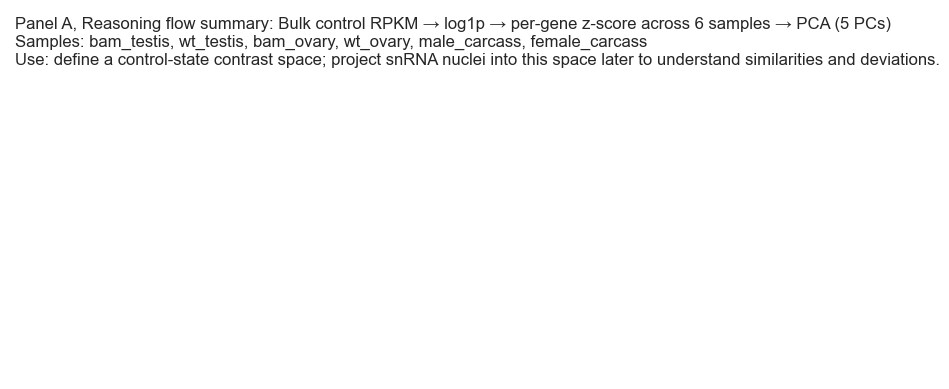

In [60]:
# PANEL A 
def panel_A_text():
    txt = (
        "Panel A, Reasoning flow summary: Bulk control RPKM → log1p → per-gene z-score across 6 samples → PCA (5 PCs)\n"
        "Samples: bam_testis, wt_testis, bam_ovary, wt_ovary, male_carcass, female_carcass\n"
        "Use: define a control-state contrast space; project snRNA nuclei into this space later to understand similarities and deviations."
    )
    plt.figure()
    plt.axis("off")
    plt.text(0.01, 0.98, txt, va="top", fontsize=12)
    plt.show()

panel_A_text()

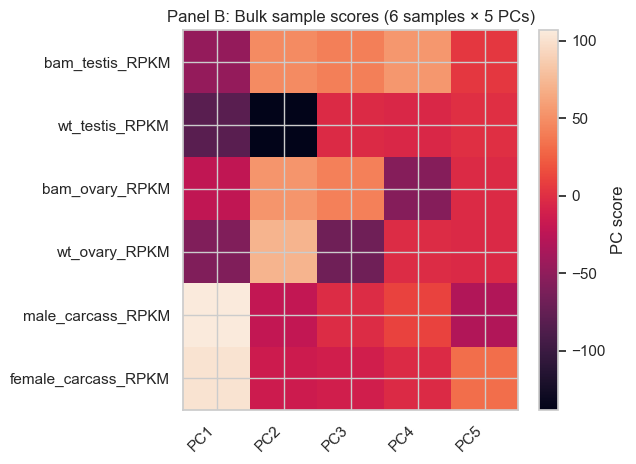

In [61]:
def panel_B_heatmap(scores_df: pd.DataFrame):
    plt.figure()
    plt.imshow(scores_df.values, aspect="auto")
    plt.xticks(range(scores_df.shape[1]), scores_df.columns, rotation=45, ha="right")
    plt.yticks(range(scores_df.shape[0]), scores_df.index)
    plt.title("Panel B: Bulk sample scores (6 samples × 5 PCs)")
    plt.colorbar(label="PC score")
    plt.tight_layout()
    plt.show()

panel_B_heatmap(bulk_scores_df)

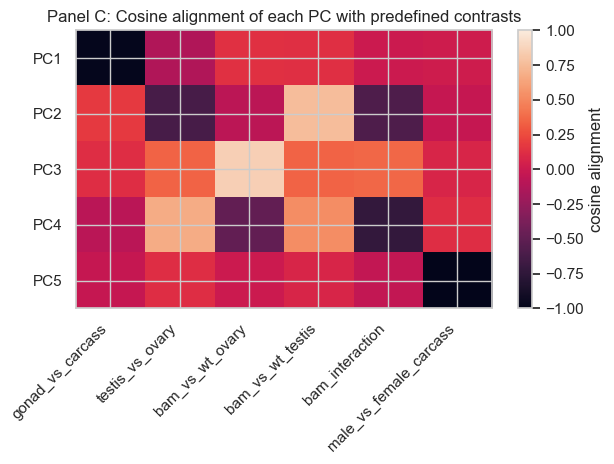

In [62]:
# Contrast alignment matrix
def panel_C_alignment(alignment_df: pd.DataFrame):
    A = alignment_df.loc[:, list(contrasts.keys())].values
    plt.figure()
    plt.imshow(A, aspect="auto", vmin=-1, vmax=1)
    plt.xticks(range(len(contrasts)), list(contrasts.keys()), rotation=45, ha="right")
    plt.yticks(range(alignment_df.shape[0]), alignment_df.index)
    plt.title("Panel C: Cosine alignment of each PC with predefined contrasts")
    plt.colorbar(label="cosine alignment")
    plt.tight_layout()
    plt.show()

panel_C_alignment(alignment_df)

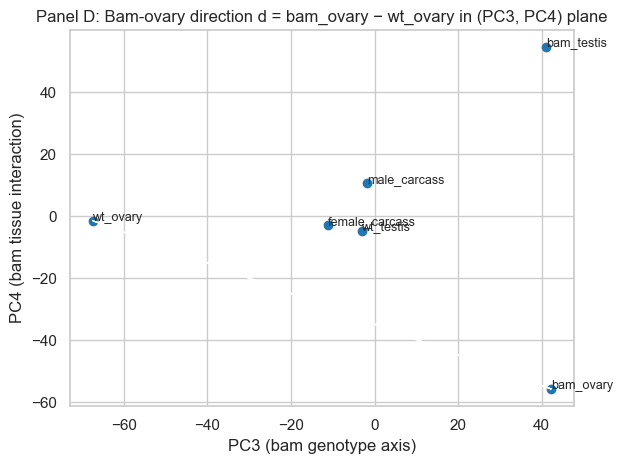

In [64]:
def panel_D_bamness_scatter(df: pd.DataFrame):
    plt.figure()
    x = df["PC3"].values
    y = df["PC4"].values

    plt.scatter(x, y)
    for name, xi, yi in zip(df.index, x, y):
        plt.text(xi, yi, name.replace("_RPKM", ""), fontsize=9)

    # Arrow: wt_ovary -> bam_ovary (handle alias if present)
    wt = "wt_ovary_RPKM"
    bam_candidates = ["bam_ovary_RPKM", "bam_ovary_knockout_RPKM"]
    bam = next((c for c in bam_candidates if c in df.index), None)

    if wt not in df.index:
        raise KeyError(f"Expected '{wt}' in df.index; got: {df.index.to_list()}")
    if bam is None:
        raise KeyError(f"Expected one of {bam_candidates} in df.index; got: {df.index.to_list()}")

    a = df.loc[wt, ["PC3", "PC4"]].values
    b = df.loc[bam, ["PC3", "PC4"]].values
    plt.arrow(a[0], a[1], b[0] - a[0], b[1] - a[1], length_includes_head=True)

    plt.xlabel("PC3 (bam genotype axis)")
    plt.ylabel("PC4 (bam tissue interaction)")
    plt.title(
        f"Panel D: Bam-ovary direction d = {bam.replace('_RPKM', '')} − {wt.replace('_RPKM', '')} in (PC3, PC4) plane"
    )
    plt.tight_layout()
    plt.show()

panel_D_bamness_scatter(bulk_scores_df)

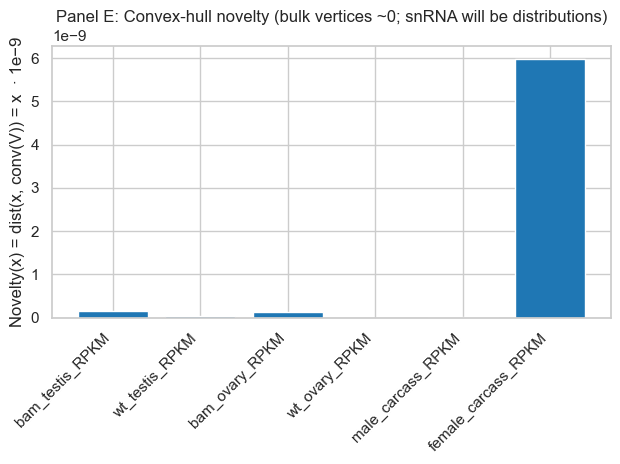

In [67]:
def panel_E_novelty_bar(novelty_df: pd.DataFrame):
    plt.figure()
    vals = novelty_df["novelty"].values
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), novelty_df.index, rotation=45, ha="right")
    plt.ylabel("Novelty(x) = dist(x, conv(V)) = x  · 1e−9")
    plt.title("Panel E: Convex-hull novelty (bulk vertices ~0; snRNA will be distributions)")
    plt.tight_layout()
    plt.show()

panel_E_novelty_bar(novelty_df)

--------------------------------END OF RPKM ANALYSIS-----------------------------------

===========================================================================

### (Optional) Bootstrap PC stability

With many bulk samples/replicates, you can estimate which PCs replicate under bootstrap resampling of samples (sign-invariant loading similarity).

**In this workshop dataset we only have 6 bulk samples (max rank = 5 PCs).** Sample-bootstrap stability is therefore underpowered and often flags most/all PCs as “unstable” even when the axes are biologically interpretable. So below we keep the **Z-matrix sanity check**, but **skip bootstrap-based PC selection** for small-
\(n\) bulk datasets and just use all PCs.


In [69]:
# Bulk Z matrix used to train the PCA model (log1p + per-gene z-score using bulk training stats)
x_bulk_log1p = np.log1p(bulk_rpkm.loc[:, model.genes].to_numpy(dtype=float, copy=False))
z_bulk = (x_bulk_log1p - model.mean_) / model.scale_

# Sanity check: reconstruct bulk scores from Z and loadings (should match fit_bulk_pca_model output)
bulk_scores_hat = (z_bulk - z_bulk.mean(axis=0)) @ model.loadings_
print("max|bulk_scores_hat - bulk_scores|:", float(np.max(np.abs(bulk_scores_hat - bulk_scores))))

# Bootstrap-based stability is only meaningful with enough bulk samples.
# With very small n (e.g. 6 samples here), sample bootstrap is underpowered and often marks most PCs as unstable.
# For the workshop, we therefore skip PC dropping and just use all PCs.
if z_bulk.shape[0] < 10:
    stability = None
    model_stable = model
    print(f"Only {z_bulk.shape[0]} bulk samples; skipping bootstrap PC stability selection (using all PCs).")
else:
    stability = bootstrap_pc_stability(
        z_bulk,
        model.loadings_,
        n_bootstrap=100,
        random_state=0,
    )

    thr = 0.85
    stable_pcs = np.flatnonzero(stability >= thr)
    model_stable = model.subset_pcs(stable_pcs) if len(stable_pcs) else model

    print(f"Stability threshold: {thr}")
    print(f"Stable PCs: {len(stable_pcs)} / {model.n_pcs}")


max|bulk_scores_hat - bulk_scores|: 2.5579538487363607e-13
Only 6 bulk samples; skipping bootstrap PC stability selection (using all PCs).


## Visualize PC vs convex-hull projection (Plotly)

We pick a single example nucleus in bulk PC space, compute its closest convex-hull point \(y^*\) and barycentric weights \(a^*\), then visualize:
- a 2D **witness plane** where the x-axis is the novelty direction \(u_1\) and the y-axis is the bam-ovary direction orthogonalized vs \(u_1\)
- a 3D **hull shadow** in (PC2, PC3, PC4)
- a stacked bar of the 6 hull weights plus the novelty scalar


In [ ]:
# NOTE: requires plotly. If you haven't yet, install with:
#   conda install -n rpkm-workshop -c conda-forge plotly

import numpy as np
from scipy.spatial import ConvexHull

try:
    import plotly.graph_objects as go
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "Plotly is required for these visualizations. Install with:\n"
        "  conda install -n rpkm-workshop -c conda-forge plotly\n"
    ) from e

# ----------------------------
# 0) Pick an example nucleus
# ----------------------------
X = np.asarray(adata.obsm["X_bulk_pcs"])  # cells × K
n_cells, k = X.shape

if k != bulk_scores_df.shape[1]:
    print(
        f"Warning: snRNA PC dimension k={k} != bulk_scores_df PCs={bulk_scores_df.shape[1]}. "
        "Ensure you're using a consistent PC space for the hull."
    )

# Choose the most out-of-hull nucleus among an evenly-spaced subset (deterministic, cheap).
n_check = min(300, n_cells)
candidate_idx = np.linspace(0, n_cells - 1, num=n_check, dtype=int)

dists = np.zeros(n_check, dtype=float)
ys = [None] * n_check
ws = [None] * n_check

for i, idx in enumerate(candidate_idx):
    dist_i, w_i, y_i = hull_projection_named(X[idx])
    dists[i] = dist_i
    ws[i] = w_i
    ys[i] = y_i

best_i = int(np.argmax(dists))
cell_idx = int(candidate_idx[best_i])
cell_name = str(adata.obs_names[cell_idx])

x = X[cell_idx]
dist = float(dists[best_i])
weights = ws[best_i]
y = ys[best_i]

print(f"Example nucleus: {cell_name} (idx={cell_idx})")
print(f"Novelty (5D dist to hull): {dist:.6g}")

# ----------------------------
# 1) 2D witness plane
# ----------------------------
# u1 = novelty direction (points from y* to x)
r = x - y
if dist <= 1e-12:
    raise ValueError(
        "Chosen example nucleus has ~0 novelty (inside hull). "
        "Increase n_check or pick another nucleus."
    )

u1 = r / dist

# u2 = bam-ovary direction d, orthogonalized vs u1
wt = "wt_ovary_RPKM"
bam_candidates = ["bam_ovary_RPKM", "bam_ovary_knockout_RPKM"]
bam = next((c for c in bam_candidates if c in bulk_scores_df.index), None)
if bam is None:
    raise KeyError(f"Expected one of {bam_candidates} in bulk_scores_df.index; got {bulk_scores_df.index.to_list()}")

d = bulk_scores_df.loc[bam].to_numpy(dtype=float) - bulk_scores_df.loc[wt].to_numpy(dtype=float)

d_orth = d - np.dot(d, u1) * u1
norm_d_orth = float(np.linalg.norm(d_orth))
if norm_d_orth <= 1e-12:
    # Very rare: d is ~parallel to u1 for this example nucleus. Fall back to a PC axis.
    e = np.eye(len(u1))
    j = int(np.argmin(np.abs(e @ u1)))
    d_orth = e[j] - np.dot(e[j], u1) * u1
    norm_d_orth = float(np.linalg.norm(d_orth))
    print("Warning: bam-ovary direction was ~parallel to novelty direction; using a fallback in-hull axis for u2.")

u2 = d_orth / norm_d_orth


def plane_coords(p: np.ndarray) -> tuple[float, float]:
    q = np.asarray(p, float) - y  # origin at y*
    return float(np.dot(q, u1)), float(np.dot(q, u2))


bulk_plane = np.array([plane_coords(bulk_scores_df.loc[name].values) for name in bulk_scores_df.index], dtype=float)
x_plane = plane_coords(x)  # should be (~dist, ~0)

# Convex hull of projected bulk vertices (projection(conv(V)) == conv(projection(V)))
h2 = ConvexHull(bulk_plane, qhull_options="QJ")
hv = h2.vertices
hx = np.r_[bulk_plane[hv, 0], bulk_plane[hv[0], 0]]
hy = np.r_[bulk_plane[hv, 1], bulk_plane[hv[0], 1]]

fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=hx,
        y=hy,
        mode="lines",
        fill="toself",
        name="proj(conv(bulk))",
        line=dict(color="rgba(0,0,0,0.25)"),
        fillcolor="rgba(0,0,0,0.05)",
        hoverinfo="skip",
    )
)

fig2.add_trace(
    go.Scatter(
        x=bulk_plane[:, 0],
        y=bulk_plane[:, 1],
        mode="markers+text",
        text=list(bulk_scores_df.index),
        textposition="top center",
        name="bulk vertices",
        marker=dict(size=10, color="#1f77b4"),
    )
)

fig2.add_trace(
    go.Scatter(
        x=[0.0],
        y=[0.0],
        mode="markers",
        name="y* (closest hull point)",
        marker=dict(size=12, color="black", symbol="x"),
    )
)

fig2.add_trace(
    go.Scatter(
        x=[x_plane[0]],
        y=[x_plane[1]],
        mode="markers",
        name="x (example nucleus)",
        marker=dict(size=12, color="#d62728"),
    )
)

ymin = float(bulk_plane[:, 1].min())
ymax = float(bulk_plane[:, 1].max())
pad = 0.1 * (ymax - ymin + 1e-12)

# Supporting hyperplane at y* is u1=0 (all hull points satisfy u1<=0).
fig2.add_shape(
    type="line",
    x0=0,
    x1=0,
    y0=ymin - pad,
    y1=ymax + pad,
    line=dict(color="black", dash="dash", width=1),
)

# Arrow y* -> x
fig2.add_annotation(
    x=x_plane[0],
    y=x_plane[1],
    ax=0,
    ay=0,
    axref="x",
    ayref="y",
    showarrow=True,
    arrowhead=3,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#d62728",
)

fig2.update_layout(
    title=f"Witness plane: novelty vs bam-ovary (orthogonalized) — novelty={dist:.3g}",
    xaxis_title="u1: novelty direction (distance out of hull)",
    yaxis_title="u2: bam-ovary direction (orthogonalized vs u1)",
    width=900,
    height=560,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
fig2.show()

# ----------------------------
# 2) 3D hull shadow (PC2-PC3-PC4)
# ----------------------------
bulk_3d = bulk_scores_df[["PC2", "PC3", "PC4"]].to_numpy(dtype=float)
x3 = np.asarray([x[1], x[2], x[3]], dtype=float)
y3 = np.asarray([y[1], y[2], y[3]], dtype=float)

h3 = ConvexHull(bulk_3d, qhull_options="QJ")
simp = h3.simplices

fig3 = go.Figure()

fig3.add_trace(
    go.Mesh3d(
        x=bulk_3d[:, 0],
        y=bulk_3d[:, 1],
        z=bulk_3d[:, 2],
        i=simp[:, 0],
        j=simp[:, 1],
        k=simp[:, 2],
        name="bulk hull (shadow)",
        color="lightgray",
        opacity=0.2,
        hoverinfo="skip",
        showscale=False,
    )
)

fig3.add_trace(
    go.Scatter3d(
        x=bulk_3d[:, 0],
        y=bulk_3d[:, 1],
        z=bulk_3d[:, 2],
        mode="markers+text",
        text=list(bulk_scores_df.index),
        name="bulk vertices",
        marker=dict(size=4, color="#1f77b4"),
        textposition="top center",
    )
)

fig3.add_trace(
    go.Scatter3d(
        x=[y3[0]],
        y=[y3[1]],
        z=[y3[2]],
        mode="markers",
        name="y* (closest hull point)",
        marker=dict(size=6, color="black", symbol="x"),
    )
)

fig3.add_trace(
    go.Scatter3d(
        x=[x3[0]],
        y=[x3[1]],
        z=[x3[2]],
        mode="markers",
        name="x (example nucleus)",
        marker=dict(size=6, color="#d62728"),
    )
)

fig3.add_trace(
    go.Scatter3d(
        x=[y3[0], x3[0]],
        y=[y3[1], x3[1]],
        z=[y3[2], x3[2]],
        mode="lines",
        name="(x − y*) shadow",
        line=dict(color="#d62728", width=5),
    )
)

fig3.update_layout(
    title="3D shadow: bulk convex hull in (PC2, PC3, PC4)",
    scene=dict(xaxis_title="PC2", yaxis_title="PC3", zaxis_title="PC4"),
    width=950,
    height=700,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
fig3.show()

# ----------------------------
# 3) Hull weights (stacked bar) + novelty scalar
# ----------------------------
weights = weights.sort_values(ascending=False)

figw = go.Figure()
for name, w in weights.items():
    figw.add_trace(go.Bar(name=str(name), y=["weights"], x=[float(w)], orientation="h"))

figw.update_layout(
    barmode="stack",
    title=f"Closest bulk-mixture weights a* (sum=1). Novelty={dist:.3g}",
    xaxis_title="weight",
    width=950,
    height=260,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
figw.show()

weights


## 1) Load snRNA-seq

This notebook assumes your snRNA AnnData is already QC'd (filtered) and log1p-normalized.
If you load raw counts, run standard normalization + log1p before projection.


In [ ]:
import anndata as ad
import scanpy as sc

if SNRNA_PATH.exists():
    adata = sc.read_h5ad(SNRNA_PATH)
    print("Loaded snRNA:", adata.shape)
else:
    rng = np.random.default_rng(1)
    n_cells = 2000
    k_latent = min(3, model_stable.n_pcs)
    latent = rng.normal(size=(n_cells, k_latent))
    w = model_stable.loadings_[:, :k_latent]  # (genes, k_latent)

    log_x = latent @ w.T + rng.normal(scale=0.55, size=(n_cells, model_stable.n_genes))
    mean_counts = np.expm1(log_x - log_x.min() + 1.0)
    counts = rng.poisson(lam=np.clip(mean_counts, 0, None)).astype(np.int32)

    adata = ad.AnnData(X=counts)
    adata.var_names = model_stable.genes.copy()
    adata.obs_names = [f"cell{i:04d}" for i in range(n_cells)]
    adata.obs["condition"] = np.where(latent[:, 0] > np.median(latent[:, 0]), "A", "B")
    print("SNRNA_PATH not found; using toy snRNA:", adata.shape)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

adata


In [ ]:
# Assumption: your AnnData has already been QC'd and log1p-normalized
# (e.g., log1p(CP10K) or log1p(size-factor-normalized counts)).

import scipy.sparse as sp

def looks_like_counts(x) -> bool:
    if sp.issparse(x):
        data = x.data
    else:
        data = np.asarray(x).ravel()
    if data.size == 0:
        return False
    if not np.all(np.isfinite(data)):
        return False
    if np.any(data < 0):
        return False
    # Heuristic: integer-valued nonnegative matrix often indicates raw counts
    return bool(np.all(np.equal(np.mod(data, 1), 0)))

print("adata.X dtype:", getattr(adata.X, "dtype", type(adata.X)))
print("scanpy log1p metadata:", adata.uns.get("log1p", None))
print("looks like raw counts:", looks_like_counts(adata.X))

# OPTIONAL (uncomment if needed):
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

adata


## 3) Project nuclei into bulk PC space (program scores)

Program scores are computed as `S = ((X_log1p - mu_bulk) / sigma_bulk) @ L`.


In [ ]:
from pathlib import Path

# Save the bulk PCA model artifact (so model_path is defined and points to a real file).
if "RESULTS_DIR" in globals():
    _results_dir = Path(RESULTS_DIR)
elif "repo_root" in globals():
    _results_dir = Path(repo_root) / "results"
else:
    _results_dir = Path.cwd() / "results"

_results_dir.mkdir(exist_ok=True)
model_path = _results_dir / "bulk_pca_model.npz"
model_stable.save_npz(model_path)

scores, info = project_log1p_to_bulk_pcs(
    adata.X,
    adata.var_names,
    model_stable,
    on_missing="warn",
    include_missing_offset=True,
)

adata.obsm["X_bulk_pcs"] = scores
for i in range(scores.shape[1]):
    adata.obs[f"bulkPC{i+1}"] = scores[:, i]

adata.uns["bulk_pca_metric"] = {
    **info,
    "model_path": str(model_path),
}

info
